In [1]:
from Bio import SeqIO
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

In [2]:
#!pip install biopython

In [3]:
# Ruta al archivo FASTA que deseas leer
def get_library_superfamilies(path):
    superfamilies = []
    # Leer el archivo FASTA usando SeqIO.parse()
    with open(path, "r") as file:
        for record in SeqIO.parse(file, "fasta"):
            superfamilies.append(record.id.split('#')[1])
    return superfamilies

In [4]:
def plot_superfamily_bar_chart(superfamilies, output_path, plot_title):
    """
    Plots a bar chart of the frequency of each superfamily and saves the plot to the given path.

    Parameters:
    superfamilies (list): List of superfamilies in the format 'CLASS/SUPERFAMILY'.
    output_path (str): The file path where the plot image will be saved.
    plot_title (str): Title for the plot.

    Returns:
    None
    """
    from collections import Counter
    import matplotlib.pyplot as plt

    # Count the frequency of each superfamily
    frequency = Counter(superfamilies)

    # Separate the keys (superfamilies) and values (frequencies)
    superfamily_names = list(frequency.keys())
    superfamily_counts = list(frequency.values())

    # Print the number of different superfamilies graphed
    print(f"Number of different superfamilies graphed: {len(superfamily_names)}")

    # Create a bar chart
    plt.figure(figsize=(12, 8))
    plt.barh(superfamily_names, superfamily_counts, color=plt.cm.Paired.colors)
    plt.xlabel('Frequency')
    plt.ylabel('Superfamilies')
    plt.title(plot_title, fontsize=16)

    # Adjust layout to avoid cutting labels
    plt.tight_layout()

    # Save the plot to the specified output path with bbox_inches='tight' to ensure the entire figure is saved
    plt.savefig(output_path, format='png', dpi=300, bbox_inches='tight')
    plt.show()

# Suzukii

Number of different superfamilies graphed: 26


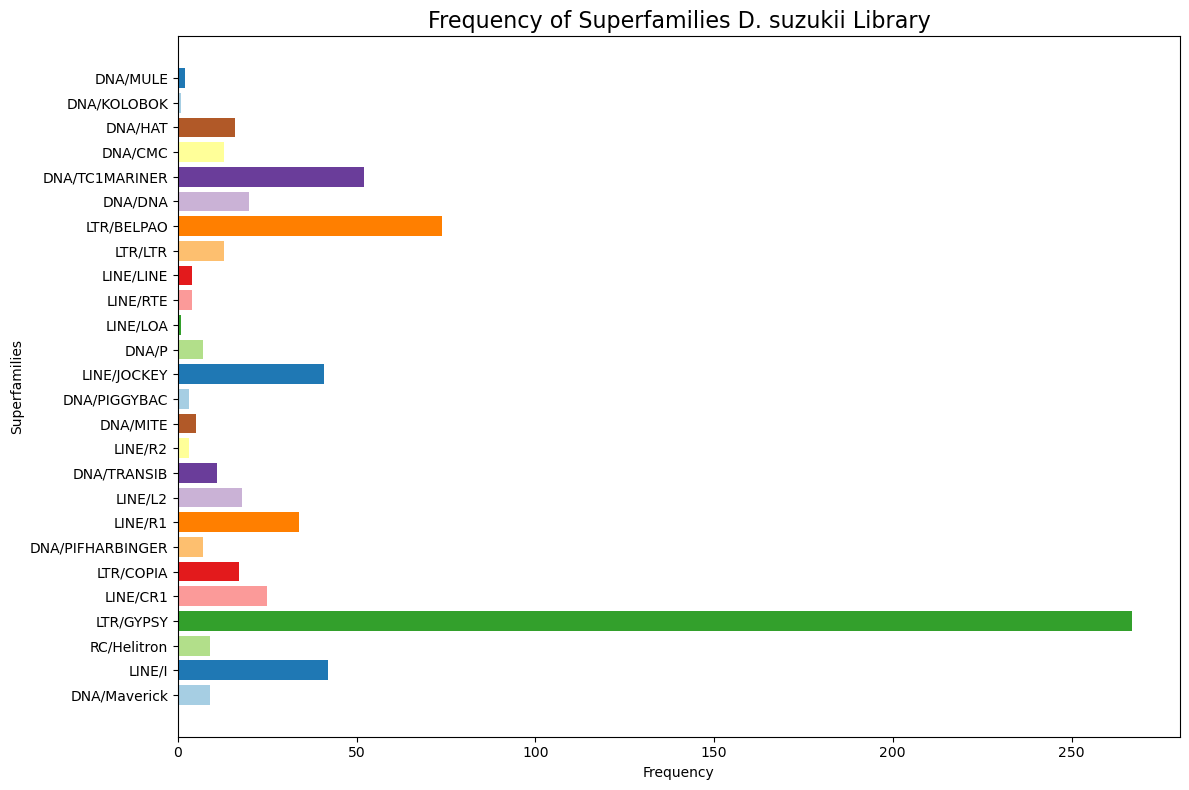

In [5]:
suzukii_superfamilies = get_library_superfamilies('ucuam_suzukii_std.fa')
plot_superfamily_bar_chart(suzukii_superfamilies, 'suzukii_superfamilies_barchart.png', 'Frequency of Superfamilies D. suzukii Library')

# Melanogaster

Number of different superfamilies graphed: 16


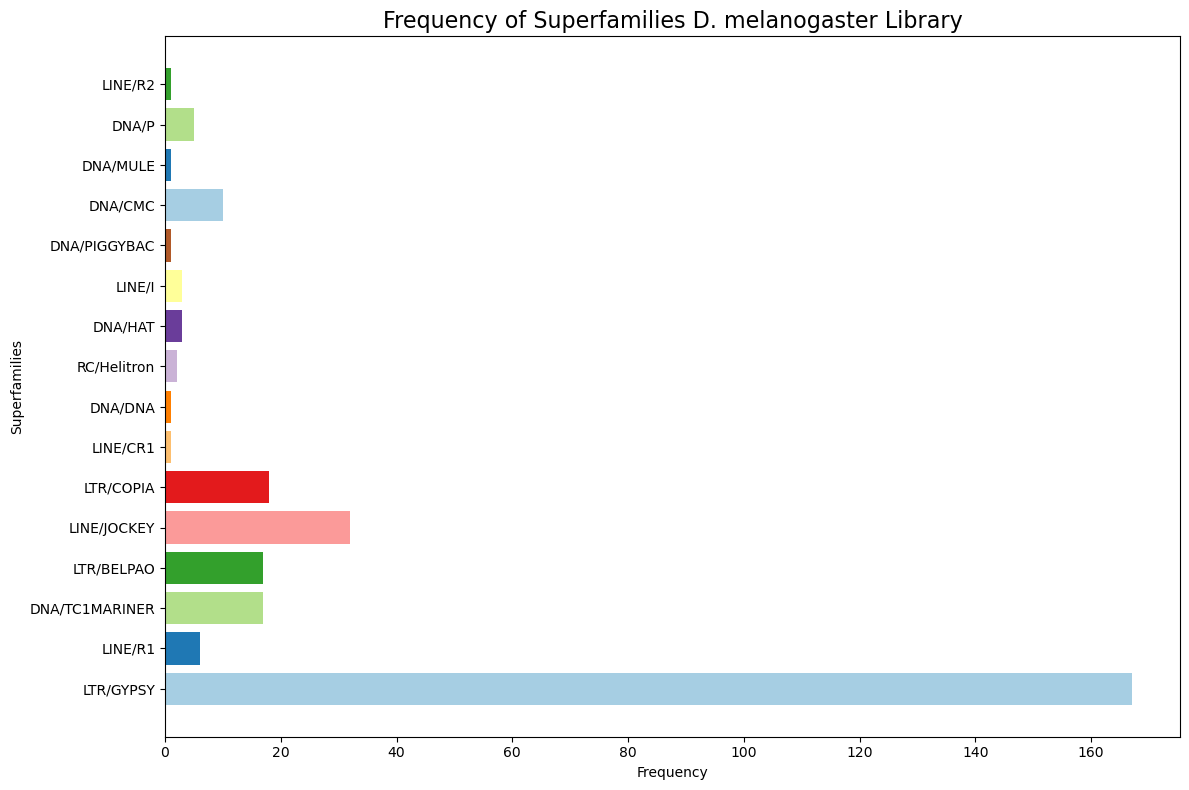

In [6]:
melanogster_superfamilies = get_library_superfamilies('melano_std.fa')
plot_superfamily_bar_chart(melanogster_superfamilies, 'melanogaster_superfamilies_barchart.png', 'Frequency of Superfamilies D. melanogaster Library')

In [7]:
def plot_superfamily_bar_chart_with_improvements(superfamilies_suzukii, superfamilies_melanogaster, output_path, plot_title):
    """
    Plots a grouped bar chart of the frequency of each superfamily for D. suzukii and D. melanogaster,
    with frequency values annotated on each bar, improved font size, color, and spacing.
    """
    from collections import Counter
    import matplotlib.pyplot as plt
    import numpy as np

    # Count the frequency of each superfamily in each species
    frequency_suzukii = Counter(superfamilies_suzukii)
    frequency_melanogaster = Counter(superfamilies_melanogaster)

    # Get the unique superfamily names across both species
    all_superfamilies = sorted(set(frequency_suzukii.keys()).union(frequency_melanogaster.keys()))

    # Get the frequencies for each superfamily in each species
    suzukii_counts = [frequency_suzukii.get(sf, 0) for sf in all_superfamilies]
    melanogaster_counts = [frequency_melanogaster.get(sf, 0) for sf in all_superfamilies]

    # Calcular el valor máximo para ajustar los márgenes dinámicamente
    max_val = max(suzukii_counts + melanogaster_counts) if (suzukii_counts + melanogaster_counts) else 0

    # Plotting
    bar_width = 0.35
    index = np.arange(len(all_superfamilies))

    plt.figure(figsize=(12, len(all_superfamilies) * 0.4 + 2)) # Ajuste dinámico de altura si son muchos datos

    # Custom color palette (MANTENIDA)
    custom_palette = ["#66c2a5", "#fc8d62"]  # Colors for D. suzukii and D. melanogaster

    # Bars for each species
    bars_suzukii = plt.barh(index, suzukii_counts, bar_width, label=r'$\it{D.\ suzukii}$', color=custom_palette[0])
    bars_melano = plt.barh(index + bar_width, melanogaster_counts, bar_width, label=r'$\it{D.\ melanogaster}$', color=custom_palette[1])

    # --- MEJORA DE ETIQUETAS ---
    # Calculamos un offset (separación) basado en el 1% del valor máximo para que no quede pegado
    offset = max_val * 0.01 

    # Función auxiliar para poner etiquetas
    def annotate_bars(bars):
        for bar in bars:
            width = bar.get_width()
            # Coloca el texto un poco más separado (width + offset)
            plt.text(width + offset, 
                     bar.get_y() + bar.get_height() / 2, 
                     f'{int(width)}',
                     va='center', ha='left', fontsize=8, color='dimgray')

    annotate_bars(bars_suzukii)
    annotate_bars(bars_melano)

    # Labeling and axis adjustments
    plt.xlabel('Frequency')
    plt.ylabel('Superfamilies')
    plt.title(plot_title, fontsize=16)
    plt.yticks(index + bar_width / 2, all_superfamilies)
    plt.legend()

    # --- AJUSTE DE LÍMITES Y TICKS ---
    # Custom x-axis ticks: extendemos el rango un poco más para que quepan los números
    limit_with_padding = max_val * 1.15
    plt.xticks(np.arange(0, limit_with_padding, step=25))
    
    # Forzar el límite del eje X para dar "aire" a la derecha
    plt.xlim(0, limit_with_padding)

    # Remove background grid and adjust layout
    plt.grid(axis='x', linestyle='--', linewidth=0.5, color='lightgray')
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    # Save the plot
    plt.tight_layout()
    plt.savefig(output_path, format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

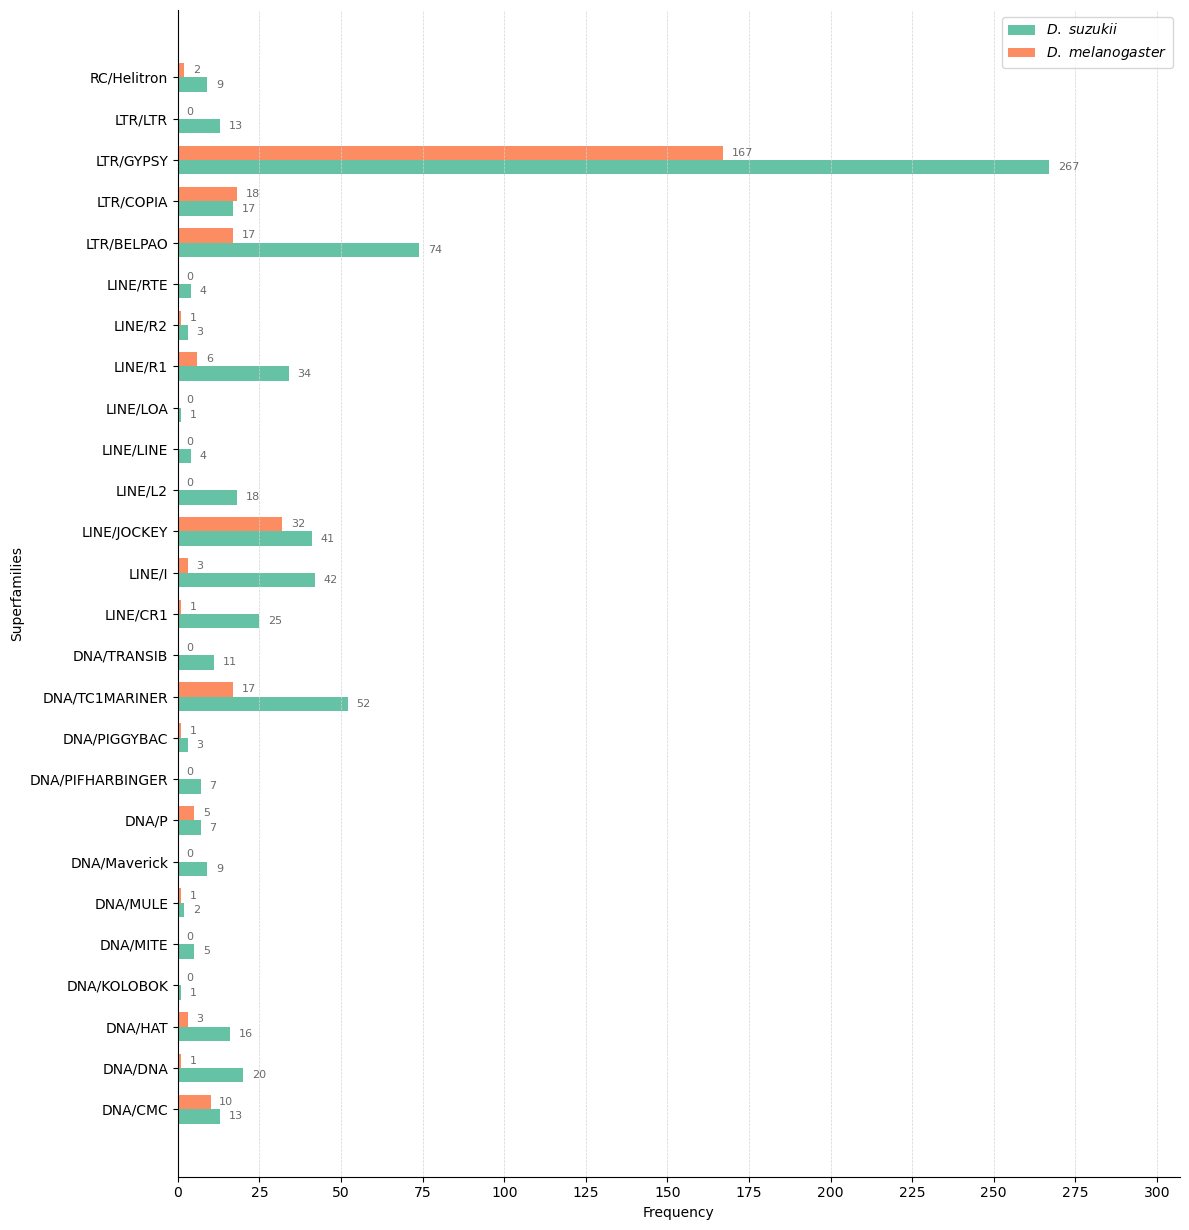

In [8]:
suzukii_superfamilies = get_library_superfamilies('ucuam_suzukii_std.fa')
melanogster_superfamilies = get_library_superfamilies('melano_std.fa')
plot_superfamily_bar_chart_with_improvements(
    suzukii_superfamilies,
    melanogster_superfamilies,
    output_path='superfamilies_in_each_library_both_species.pdf',
    plot_title=''
)

# Nueva lib melano

In [9]:
melanogster_superfamilies = get_library_superfamilies('curated_lib/drosophila_completa.fasta')
plot_superfamily_bar_chart(melanogster_superfamilies, 'curated_lib/article_melanogaster_superfamilies_barchart.png', 'Frequency of Superfamilies D. melanogaster Library')

FileNotFoundError: [Errno 2] No such file or directory: 'curated_lib/drosophila_completa.fasta'

In [ ]:
suzukii_superfamilies = get_library_superfamilies('curated_lib/ucuam_suzukii_v.1.3.fa')
melanogster_superfamilies = get_library_superfamilies('curated_lib/drosophila_completa.fasta')
plot_superfamily_bar_chart_with_improvements(
    suzukii_superfamilies,
    melanogster_superfamilies,
    output_path='article_superfamilies_in_each_library_both_species_article.png',
    plot_title=''
)